In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
# from scipy.io import readsav
# from pathlib import Path
import maos_utils as mu
from scipy import signal
# from astropy.io import fits
from PyAstronomy import pyasl # type: ignore
import astropy.units as u

In [34]:
def sci_format(x, lim):
    return '{:.8e}'.format(x)

In [35]:
def rms_wfe_KAON113(wvl, r0, SNR, theta_gs=1.93, ctrlloop=0.393, d=0.5625):
    ( ( wvl / ( (8 / (3*np.pi)) * ( np.exp(-0.115 * (d/r0)) + np.exp(-0.155 * (d/r0)**2.0) ) ) ) + ( ( np.pi*d*theta_gs ) / 8.0 ) ) * (ctrlloop/SNR)
    return

##### This telemetry file corresponds to science image ``i240807_a047047.fits``, which has a Strehl of 0.297, FWHM of 60.16 mas, and an RMS WFE of 371.8 nm, according to ``strehl_source.txt`` in directory ``/g/lu/data/microlens/24aug07os/clean/ob230215_kp_tdOpen``. As a result we can say this was a fair/good quality image (not great), so we expect similar signs within the telemetry below of good quality. Based on directory name, the object under observation in this science image is OB230215. From Macy Houston, this is microlensing object OGLE-2023-BLG-0215

In [36]:
# Convert magnitude to flux density based on Bessel et al. 1998
mag_I = 19.4 # from https://ogle.astrouw.edu.pl/ogle4/ews/2023/blg-0215.html
fd_nu, le = pyasl.magToFluxDensity_bessel98("I", mag_I, "nu")
print("I-band magnitude: ", mag_I)
print("I-band flux density [erg/cm**2/s/Hz]: ", fd_nu)

I-band magnitude:  19.4
I-band flux density [erg/cm**2/s/Hz]:  4.199523346640699e-28


### **Load in telemetry**

##### **Down tip/tilt**

In [37]:
root = '/g/lu/data/keck_telemetry/20240807'
down_tt = f'{root}/LGS-downtiptilt-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'

In [38]:
down_tt_telemetry = np.load(down_tt)

In [39]:
print(list(down_tt_telemetry.keys()))

['rawtimestamp', 'timestamp', 'frameCounter', 'TTslope', 'DTTMirrorCommand']


In [40]:
down_tt_telemetry.files

['rawtimestamp', 'timestamp', 'frameCounter', 'TTslope', 'DTTMirrorCommand']

In [41]:
down_tt_telemetry['rawtimestamp']

array([1.72301397e+18, 1.72301397e+18, 1.72301397e+18, ...,
       1.72301401e+18, 1.72301401e+18, 1.72301401e+18])

In [42]:
down_tt_centroids_x = down_tt_telemetry['TTslope'][:,0]
down_tt_centroids_y = down_tt_telemetry['TTslope'][:,1]

##### **Up Tip/tilt**

In [43]:
up_tt = f'{root}/LGS-uptiptilt-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'
up_tt_telemetry = np.load(up_tt)

In [44]:
up_tt_telemetry.files

['rawtimestamp',
 'timestamp',
 'frameCounter',
 'SHWFS1TT',
 'UTTMainMirrorCommand']

In [45]:
up_tt_x = up_tt_telemetry['SHWFS1TT'][:,0]
up_tt_y = up_tt_telemetry['SHWFS1TT'][:,1]

##### **STRAP**

In [46]:
strap = f'{root}/LGS-straprtc-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'
strap_telemetry = np.load(strap)

In [47]:
strap_telemetry.files

['rawtimestamp', 'timestamp', 'frameCounter', 'STRAPImage', 'STRAPCentroid']

In [48]:
(np.max(strap_telemetry['rawtimestamp']) - np.min(strap_telemetry['rawtimestamp'])) / (1e9)

39.996333312

In [49]:
strap_telemetry['STRAPCentroid']

array([[-0.03740734, -0.02674329],
       [ 0.05046558, -0.1793732 ],
       [ 0.12388635, -0.13989264],
       ...,
       [-0.12850273, -0.0136981 ],
       [-0.05743295, -0.0157221 ],
       [-0.0374859 , -0.04811567]])

In [50]:
strap_telemetry['STRAPImage']

array([[ 95., 127., 116.,  86.],
       [ 88., 121.,  80.,  73.],
       [ 68., 131.,  87.,  67.],
       ...,
       [ 80., 104., 105.,  64.],
       [ 76., 125., 118.,  67.],
       [ 87., 110.,  96.,  77.]])

##### **OCAM2K**

In [51]:
ocam2k = f'{root}/LGS-ocam2k-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'
ocam2k_telemetry = np.load(ocam2k)

In [52]:
ocam2k_telemetry.files

['rawtimestamp',
 'timestamp',
 'frameCounter',
 'SHWFS1Centroid',
 'SHWFS1SubAper']

In [53]:
ocam2k_telemetry['SHWFS1SubAper'].shape

(30000, 304)

In [54]:
np.mean(np.diff(ocam2k_telemetry['rawtimestamp']))*(1e-9) # seconds

0.0010000533543118105

OCAM2K running at 1 kHz for this telemetry data

##### **Xinetics**

In [55]:
xinetics = f'{root}/LGS-xinetics-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'
xinetics_telemetry = np.load(xinetics)

In [56]:
xinetics_telemetry.files

['rawtimestamp', 'timestamp', 'frameCounter', 'residualWaveFront', 'DMCommand']

In [57]:
xinetics_telemetry['residualWaveFront']

array([[ 7.24015713,  3.48153567,  2.73270988, ..., -0.07795916,
         0.17388219,  1.49046731],
       [ 7.64563847,  4.18183565,  3.12334394, ...,  0.24793935,
         0.01165447,  1.48592114],
       [ 8.3049736 ,  4.78770065,  3.16448212, ..., -0.13764608,
         0.12277693,  2.49442339],
       ...,
       [ 7.45466709,  4.129179  ,  2.52962208, ...,  0.48750174,
         0.86794615,  2.77267623],
       [ 7.96255207,  4.62483978,  2.85610604, ..., -0.13283551,
         0.14456391,  2.40308714],
       [ 8.83214569,  5.44389629,  2.97767448, ...,  0.84243381,
         0.9251591 ,  2.84610343]])

##### **Strain Gauge**

In [58]:
gauge = f'{root}/LGS-clmpstraingauge-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'
clmpstraingauge = np.load(gauge)

In [59]:
clmpstraingauge.files

['rawtimestamp',
 'timestamp',
 'frameCounter',
 'DTTStrainGauge',
 'UTTMainStrainGauge']

In [60]:
clmpstraingauge['UTTMainStrainGauge'].shape

(30000, 2)

##### **Raw SHWFS**

In [61]:
shwfs_raw = f'{root}/LGS-SHWFSraw-2024-08-07T06:59:33.007755-2024-08-07T06:59:42.998621.npz'
shwfs_raw_telemetry = np.load(shwfs_raw)

In [62]:
shwfs_raw_telemetry.files

['rawtimestamp', 'timestamp', 'SHWFS1Image']

In [63]:
shwfs_raw_telemetry['SHWFS1Image'].shape

(1000, 1600)

### **Import DM reconstructor file from Jim**

In [64]:
# np.fromfile("/Users/bdigia/code/python/paarti/paarti/utils/7Aug0025.mr").reshape((352, 608))

### **Compare STRAP and SHWFS intensities over time**

Check for cloud cover + compute STRAP WFE using centroid timestream

In [65]:
print(strap_telemetry['frameCounter'])
print(strap_telemetry['STRAPImage'])

[23877912. 23877913. 23877914. ... 23887909. 23887910. 23887911.]
[[ 95. 127. 116.  86.]
 [ 88. 121.  80.  73.]
 [ 68. 131.  87.  67.]
 ...
 [ 80. 104. 105.  64.]
 [ 76. 125. 118.  67.]
 [ 87. 110.  96.  77.]]


In [66]:
apd_channels = strap_telemetry['STRAPImage']*0.3
apd_avg_over_time = np.mean(apd_channels, axis=0)
print(apd_avg_over_time.shape)
print(np.sum(apd_avg_over_time))
# Choose a sub aperture to plot timestream intensity
sample_subaper = ocam2k_telemetry['SHWFS1SubAper']

(4,)
112.15355999999994


Use ``frameCounter`` rather than ``rawtimestamp`` from telemetry for $x$-axis. Advice from Avinash - frameCounter is synced between telemetry data groups (e.g. ``SHWFSraw`` versus ``STRAP``)

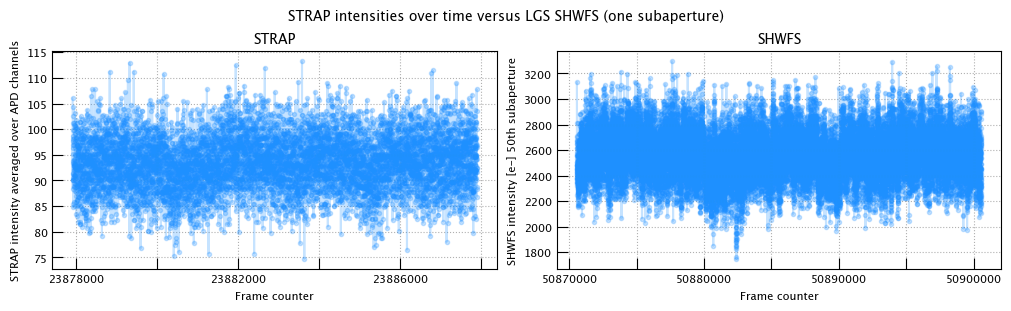

In [67]:
apd_channels = strap_telemetry['STRAPImage']
apd_avg = np.mean(apd_channels, axis=1)
# Choose a sub aperture to plot timestream intensity
sample_subaper = ocam2k_telemetry['SHWFS1SubAper']

fig = plt.figure(figsize=(10.0, 3.0), layout='constrained')
spec = fig.add_gridspec(1, 2)
fig.suptitle(f"STRAP intensities over time versus LGS SHWFS (one subaperture)", fontsize=10.0)
ax0 = fig.add_subplot(spec[0,0])
ax1 = fig.add_subplot(spec[0,1])
ax0.plot(strap_telemetry['frameCounter'], apd_avg, '.-', alpha=0.25, color='dodgerblue')
ax1.plot(ocam2k_telemetry['frameCounter'], sample_subaper[:,50]*0.508, '.-', alpha=0.25, color='dodgerblue') # multiply by gain to go from ADU to e-
ax0.set_title("STRAP", fontsize=10.0)
ax1.set_title("SHWFS", fontsize=10.0)
ax0.set_ylabel("STRAP intensity averaged over APD channels", fontsize=8.0)
ax1.set_ylabel("SHWFS intensity [e-] 50th subaperture", fontsize=8.0)
ax0.set_xlabel("Frame counter", fontsize=8.0)
ax1.set_xlabel("Frame counter", fontsize=8.0)
ax0.grid(True, linestyle='dotted')
ax1.grid(True, linestyle='dotted')
ax0.tick_params(axis='both', direction='in', labelsize=8.0)
ax1.tick_params(axis='both', direction='in', labelsize=8.0)
# ax0.xaxis.set_major_formatter(FuncFormatter(sci_format))
# ax1.xaxis.set_major_formatter(FuncFormatter(sci_format))
ax0.ticklabel_format(useOffset=False, style='plain')
ax1.ticklabel_format(useOffset=False, style='plain')
for label in ax0.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
for label in ax1.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)

No cloud cover for this night of telemetry

### **STRAP APD Intensities by channel**

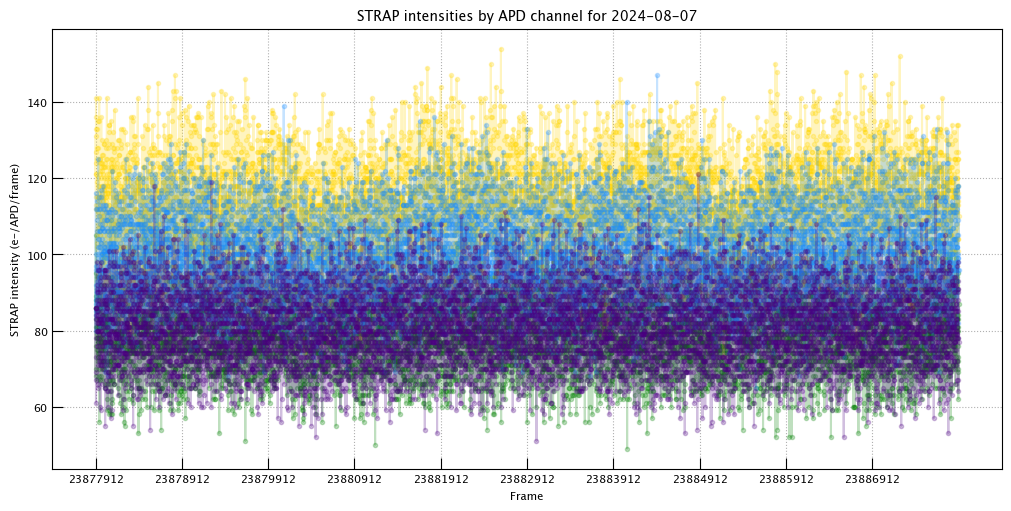

In [68]:
fig = plt.figure(figsize=(10.0, 5.0), layout='constrained')
# Multiply by highest gain STRAP can be (0.3) - multiplying by lower gains decrease intensities further
plt.plot(strap_telemetry['frameCounter'], strap_telemetry['STRAPImage'][:,0], '.-', alpha=0.25, color='green')
plt.plot(strap_telemetry['frameCounter'], strap_telemetry['STRAPImage'][:,1], '.-', alpha=0.25, color='gold')
plt.plot(strap_telemetry['frameCounter'], strap_telemetry['STRAPImage'][:,2], '.-', alpha=0.25, color='dodgerblue')
plt.plot(strap_telemetry['frameCounter'], strap_telemetry['STRAPImage'][:,3], '.-', alpha=0.25, color='indigo')
plt.grid(True, linestyle='dotted')
# plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
# for label in plt.gca().xaxis.get_ticklabels()[::2]:
#     label.set_visible(False)
plt.xticks(np.arange(min(strap_telemetry['frameCounter']), max(strap_telemetry['frameCounter'])+1, 1000.0))
plt.gca().ticklabel_format(useOffset=False, style='plain')
plt.gca().tick_params(axis='x', which='minor', bottom=True)
plt.xlabel("Frame", fontsize=8.0)
plt.ylabel("STRAP intensity (e-/APD/frame)", fontsize=8.0)
plt.title("STRAP intensities by APD channel for 2024-08-07", fontsize=10.0)
plt.gca().tick_params(axis='both', direction='in', labelsize=8.0)

##### **STRAP WFE computation**

In [69]:
np.mean(np.diff(strap_telemetry['rawtimestamp']))*(1e-6) # convert from ns to ms

4.0000333345334536

In [70]:
tip_centroids = strap_telemetry['STRAPCentroid'][:,0] # arcseconds 
tilt_centroids = strap_telemetry['STRAPCentroid'][:,1] # arcseconds
# print(tilt_centroids)
# RMS
rms_tip = np.sqrt(np.mean(pow(tip_centroids, 2))) # pyAO rms function calculation method
rms_tilt = np.sqrt(np.mean(pow(tilt_centroids, 2))) # pyAO rms function calculation method
print(f"RMS tip error = {rms_tip} arcsec | RMS tilt error = {rms_tilt} arcsec")
# Conversion factor from van Dam Performance of the Keck Observatory AO system
conv = 12.68 # microns per arcsec
rms_tip *= conv*(1000.0) # microns to nm
rms_tilt *= conv*(1000.0) # microns to nm
print(f"RMS tip error = {rms_tip} nm | RMS tilt error = {rms_tilt} nm")
# # From Lianqi conversion factor: 1 radian of tip/tilt gives R/2 m RMS OPD error
# opd_tip = ( rms_tip * ( np.pi / (180.0 * 3600.0) ) ) * (11.0 / 2.0) # meters
# # opd_tip *= (1e9) # meters to nm
# print(opd_tip)

RMS tip error = 0.07901127606551725 arcsec | RMS tilt error = 0.07684578818742391 arcsec
RMS tip error = 1001.8629805107587 nm | RMS tilt error = 974.4045942165352 nm


### **STRAP Spot size ($\theta_{\beta}$): ``maos_utils.keck_nea_photons()`` calculation versus telemetry-derived result**

In [71]:
# Numbering convention according to Avinash and Marcos 
# (order of readout of the 4 channels in TRS is 1,0,3,2)
I1 = strap_telemetry['STRAPImage'][:,0][strap_telemetry['STRAPImage'][:,0] > 1]
I0 = strap_telemetry['STRAPImage'][:,1][strap_telemetry['STRAPImage'][:,1] > 1]
I3 = strap_telemetry['STRAPImage'][:,2][strap_telemetry['STRAPImage'][:,2] > 1]
I2 = strap_telemetry['STRAPImage'][:,3][strap_telemetry['STRAPImage'][:,3] > 1]
apdsum = np.sum(strap_telemetry['STRAPImage'], axis=1)
strap_centroids_x = (I0 - I1 + I2 - I3) / apdsum
strap_centroids_y = (-I0 - I1 + I2 + I3) / apdsum

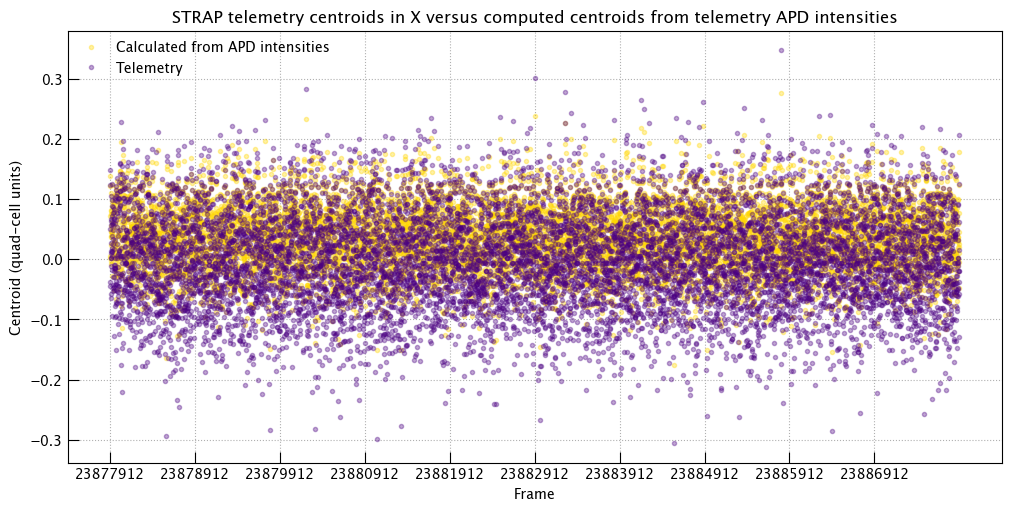

In [72]:
fig = plt.figure(figsize=(10.0, 5.0), layout='constrained')
plt.plot(strap_telemetry['frameCounter'], strap_centroids_x, '.', alpha=0.35, color='gold', linewidth=0.5, label="Calculated from APD intensities")
plt.plot(strap_telemetry['frameCounter'], tip_centroids, '.', alpha=0.35, color='indigo', linewidth=0.5, label="Telemetry")
plt.grid(True, linestyle='dotted')
# plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
# for label in plt.gca().xaxis.get_ticklabels()[::2]:
#     label.set_visible(False)
plt.xticks(np.arange(min(strap_telemetry['frameCounter']), max(strap_telemetry['frameCounter'])+1, 1000.0))
plt.gca().ticklabel_format(useOffset=False, style='plain')
plt.gca().tick_params(axis='x', which='minor', bottom=True)
plt.xlabel("Frame", fontsize=10.0)
plt.ylabel("Centroid (quad-cell units)", fontsize=10.0)
plt.title("STRAP telemetry centroids in X versus computed centroids from telemetry APD intensities", fontsize=12.0)
plt.gca().tick_params(axis='both', direction='in', labelsize=10.0)
plt.legend(frameon=False, fontsize=10)
plt.show()

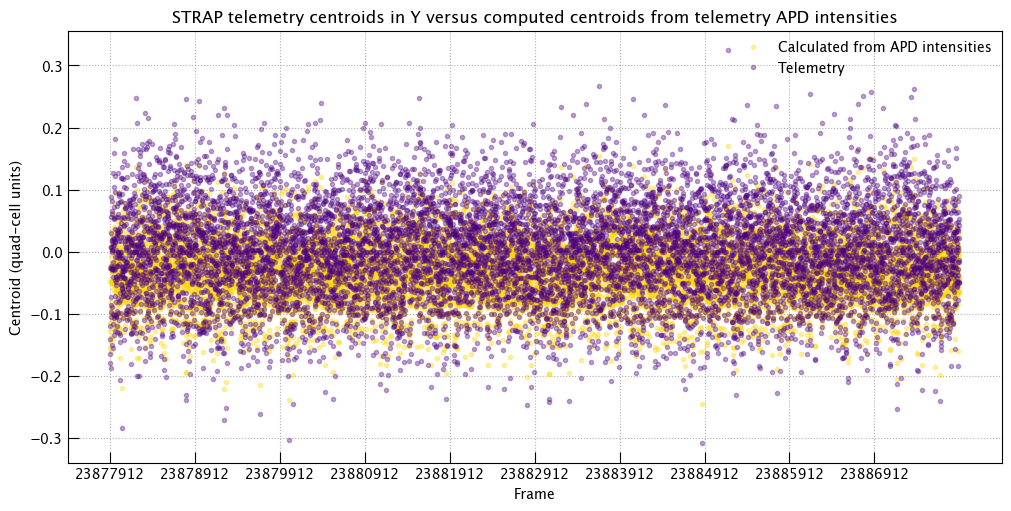

In [73]:
fig = plt.figure(figsize=(10.0, 5.0), layout='constrained')
plt.plot(strap_telemetry['frameCounter'], strap_centroids_y, '.', alpha=0.35, color='gold', linewidth=0.5, label="Calculated from APD intensities")
plt.plot(strap_telemetry['frameCounter'], tilt_centroids, '.', alpha=0.35, color='indigo', linewidth=0.5, label="Telemetry")
plt.grid(True, linestyle='dotted')
# plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
# for label in plt.gca().xaxis.get_ticklabels()[::2]:
#     label.set_visible(False)
plt.xticks(np.arange(min(strap_telemetry['frameCounter']), max(strap_telemetry['frameCounter'])+1, 1000.0))
plt.gca().ticklabel_format(useOffset=False, style='plain')
plt.gca().tick_params(axis='x', which='minor', bottom=True)
plt.xlabel("Frame", fontsize=10.0)
plt.ylabel("Centroid (quad-cell units)", fontsize=10.0)
plt.title("STRAP telemetry centroids in Y versus computed centroids from telemetry APD intensities", fontsize=12.0)
plt.gca().tick_params(axis='both', direction='in', labelsize=10.0)
plt.legend(frameon=False, fontsize=10)
plt.show()

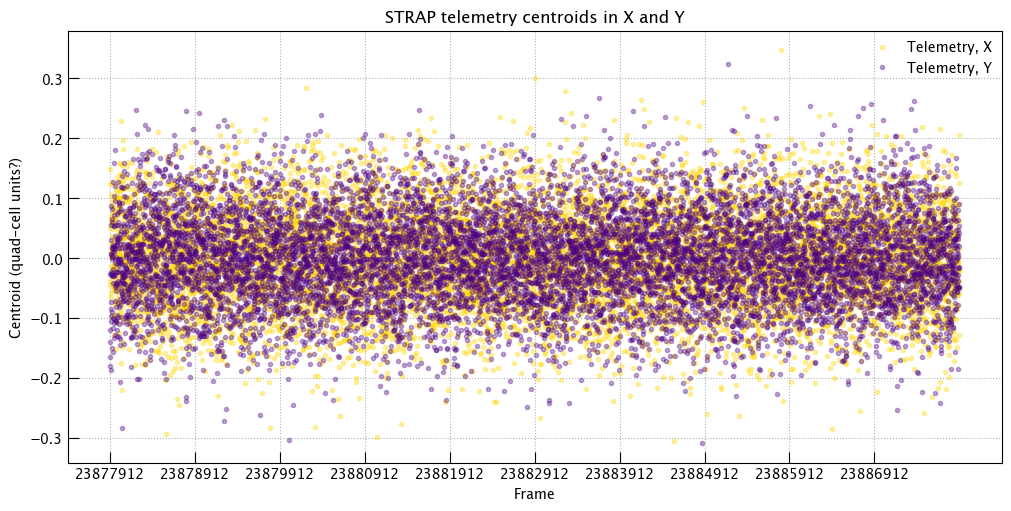

In [74]:
fig = plt.figure(figsize=(10.0, 5.0), layout='constrained')
plt.plot(strap_telemetry['frameCounter'], tip_centroids, '.', alpha=0.35, color='gold', linewidth=0.5, label="Telemetry, X")
plt.plot(strap_telemetry['frameCounter'], tilt_centroids, '.', alpha=0.35, color='indigo', linewidth=0.5, label="Telemetry, Y")
plt.grid(True, linestyle='dotted')
# plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
# for label in plt.gca().xaxis.get_ticklabels()[::2]:
#     label.set_visible(False)
plt.xticks(np.arange(min(strap_telemetry['frameCounter']), max(strap_telemetry['frameCounter'])+1, 1000.0))
plt.gca().ticklabel_format(useOffset=False, style='plain')
plt.gca().tick_params(axis='x', which='minor', bottom=True)
plt.xlabel("Frame", fontsize=10.0)
plt.ylabel("Centroid (quad-cell units?)", fontsize=10.0)
plt.title("STRAP telemetry centroids in X and Y", fontsize=12.0)
plt.gca().tick_params(axis='both', direction='in', labelsize=10.0)
plt.legend(frameon=False, fontsize=10)
plt.show()

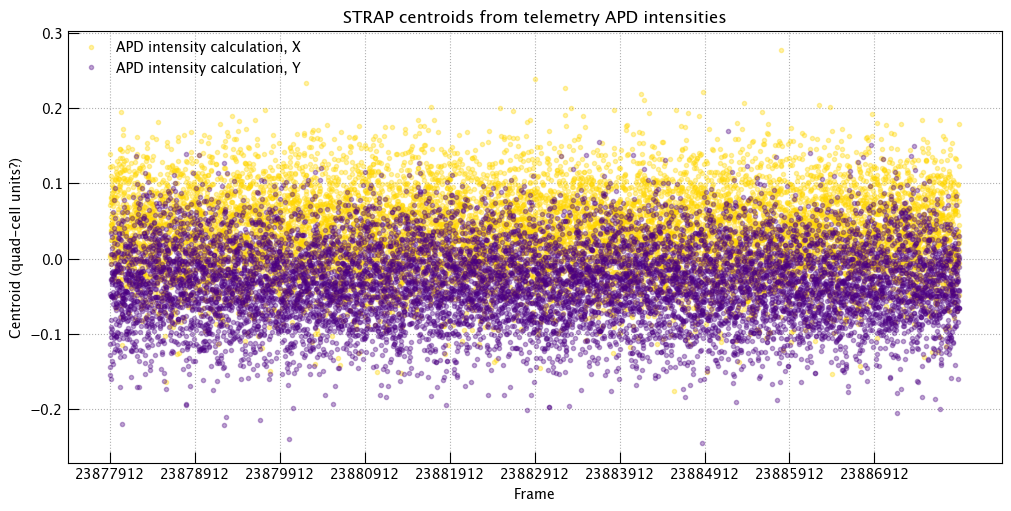

In [75]:
fig = plt.figure(figsize=(10.0, 5.0), layout='constrained')
plt.plot(strap_telemetry['frameCounter'], strap_centroids_x, '.', alpha=0.35, color='gold', linewidth=0.5, label="APD intensity calculation, X")
plt.plot(strap_telemetry['frameCounter'], strap_centroids_y, '.', alpha=0.35, color='indigo', linewidth=0.5, label="APD intensity calculation, Y")
plt.grid(True, linestyle='dotted')
# plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
# for label in plt.gca().xaxis.get_ticklabels()[::2]:
#     label.set_visible(False)
plt.xticks(np.arange(min(strap_telemetry['frameCounter']), max(strap_telemetry['frameCounter'])+1, 1000.0))
plt.gca().ticklabel_format(useOffset=False, style='plain')
plt.gca().tick_params(axis='x', which='minor', bottom=True)
plt.xlabel("Frame", fontsize=10.0)
plt.ylabel("Centroid (quad-cell units?)", fontsize=10.0)
plt.title("STRAP centroids from telemetry APD intensities", fontsize=12.0)
plt.gca().tick_params(axis='both', direction='in', labelsize=10.0)
plt.legend(frameon=False, fontsize=10)
plt.show()

Difference in x and y due to LGS elongation

#### **STRAP SNR from telemetry**

In [76]:
band_wvl = 0.641e-6*u.m

# KAON r0 equation (Roddier 1981's equation, using DIMM measurement as full atm seeing). 1.06'' as last DIMM measurement from this night according to Mauna Kea seeing center, since DIMM raw data not available at time of telemetry exposure
r0 = 0.976 * ( band_wvl.to(u.m) / mu.arcsec_to_rad(1.06*u.arcsec).to('', equivalencies=u.dimensionless_angles() ))
print(f"Telemetry Fried parameter r0 = {r0} m")

theta_r0 = mu.seeing_limit_spot_size(band_wvl, r0)
theta_beta = np.sqrt(theta_r0**2.0 + 0.625**2.0)
# Convert spot size to radians
theta_beta *= ( np.pi/180.0 ) / ( 60.0*60.0 )
print(f"STRAP spot size from convolution using 2024-08-07 telemetry = {theta_beta} rad --> {theta_beta / (( np.pi/180.0 ) / ( 60.0*60.0 ))} arcsec")

Telemetry Fried parameter r0 = 0.12173826700479569 m m
STRAP spot size from convolution using 2024-08-07 telemetry = 5.965501233499532e-06 rad --> 1.2304729560945953 arcsec


In [77]:
# Standard deviation
strap_sigma_from_tip = np.std(np.abs(tip_centroids), axis=0)
strap_sigma_from_tilt = np.std(np.abs(tilt_centroids), axis=0)
# SNR = theta (spot size) / sigma_arcsec
spot = theta_beta / (( np.pi/180.0 ) / ( 60.0*60.0 )) # arcseconds
STRAP_SNR_KAON422_tip = spot / strap_sigma_from_tip
STRAP_SNR_KAON422_tilt = spot / strap_sigma_from_tilt
print(STRAP_SNR_KAON422_tip)
print(STRAP_SNR_KAON422_tilt)
print(np.mean([STRAP_SNR_KAON422_tip, STRAP_SNR_KAON422_tilt]))

25.778983920110406
26.384610219820697
26.081797069965553


In [78]:
# Standard deviation
strap_sigma_from_tip = np.std(np.abs(strap_centroids_x), axis=0)
strap_sigma_from_tilt = np.std(np.abs(strap_centroids_y), axis=0)
# SNR = theta (spot size) / sigma_arcsec
spot = theta_beta / (( np.pi/180.0 ) / ( 60.0*60.0 )) # arcseconds
STRAP_SNR_KAON422_tip = spot / strap_sigma_from_tip
STRAP_SNR_KAON422_tilt = spot / strap_sigma_from_tilt
print(STRAP_SNR_KAON422_tip)
print(STRAP_SNR_KAON422_tilt)
print(np.mean([STRAP_SNR_KAON422_tip, STRAP_SNR_KAON422_tilt]))

31.616049496431337
33.73839128360913
32.67722039002024


#### **Higher-order RMS WFE**

In [79]:
ho_rms_wfe = np.sqrt(np.mean(np.square(xinetics_telemetry['residualWaveFront'][:,50:56])))
ho_rms_wfe *= (0.6 * 1000.0) # 0.6 microns/volts, then * 1000.0 for microns to nm
# Average over time
avg_ho_rms_wfe = np.mean(ho_rms_wfe)
print(f"Time-averaged higher-order RMS WFE from telemetry residualWaveFront = {avg_ho_rms_wfe} nm")

Time-averaged higher-order RMS WFE from telemetry residualWaveFront = 220.62364127970721 nm


### **Plot tip/tilt residuals (centroids, slopes) in X and Y**

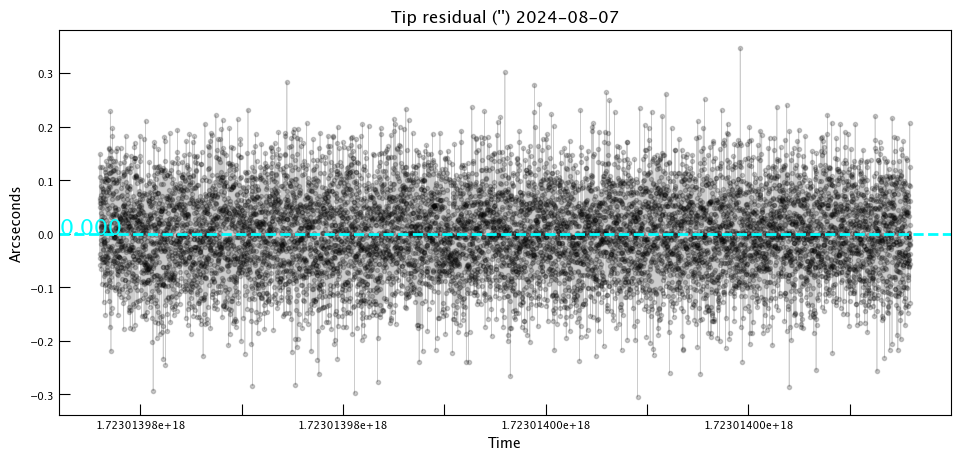

In [80]:
plt.figure(figsize=(10.0, 5.0))
plt.plot(strap_telemetry['rawtimestamp'], tip_centroids, 'k.-', linewidth=0.5, alpha=0.2)
plt.axhline(y=np.mean(tip_centroids), color='cyan', linestyle='--', linewidth=2, 
            label=r"$\bar{\mathtt{residual tip}}$ arcsec")
plt.text(plt.xlim()[0], np.mean(tip_centroids)*1.03, s=f"{np.mean(tip_centroids):.3f}", color='cyan')
plt.title("Tip residual (\'\') 2024-08-07", fontsize=12.0)
plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
plt.ylabel("Arcseconds", fontsize=10.0)
for label in plt.gca().xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xlabel("Time", fontsize=10.0)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")

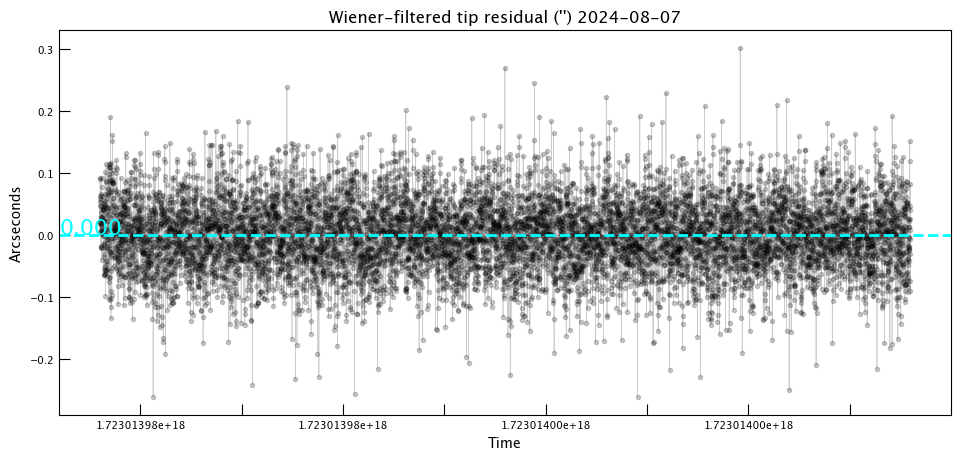

In [81]:
from scipy.signal import wiener
filtered_tip_centroids = wiener(tip_centroids) # Use noise=None so that function estimates noise as the average of the local variance of input tip centroids

plt.figure(figsize=(10.0, 5.0))
plt.plot(strap_telemetry['rawtimestamp'], filtered_tip_centroids, 'k.-', linewidth=0.5, alpha=0.2)
plt.axhline(y=np.mean(filtered_tip_centroids), color='cyan', linestyle='--', linewidth=2, 
            label=r"$\bar{\mathtt{residual tip}}$ arcsec")
plt.text(plt.xlim()[0], np.mean(filtered_tip_centroids)*1.03, s=f"{np.mean(filtered_tip_centroids):.3f}", color='cyan')
plt.title("Wiener-filtered tip residual (\'\') 2024-08-07", fontsize=12.0)
plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
plt.ylabel("Arcseconds", fontsize=10.0)
for label in plt.gca().xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xlabel("Time", fontsize=10.0)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")

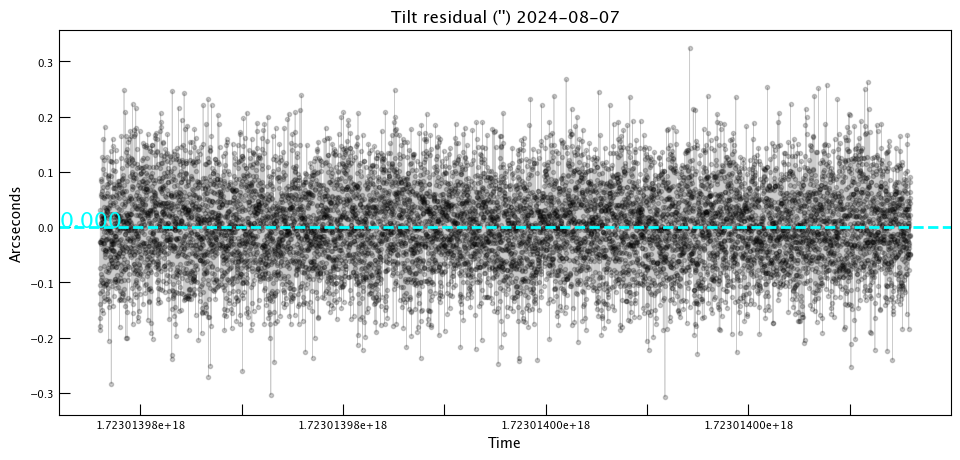

In [82]:
plt.figure(figsize=(10.0, 5.0))
plt.plot(strap_telemetry['rawtimestamp'], tilt_centroids, 'k.-', linewidth=0.5, alpha=0.2)
plt.axhline(y=np.mean(tilt_centroids), color='cyan', linestyle='--', linewidth=2, 
            label=r"$\bar{\mathtt{residual tilt}}$ arcsec")
plt.text(plt.xlim()[0], np.mean(tilt_centroids)*1.03, s=f"{np.mean(tilt_centroids):.3f}", color='cyan')
plt.title("Tilt residual (\'\') 2024-08-07", fontsize=12.0)
plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
plt.ylabel("Arcseconds", fontsize=10.0)
for label in plt.gca().xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xlabel("Time", fontsize=10.0)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")

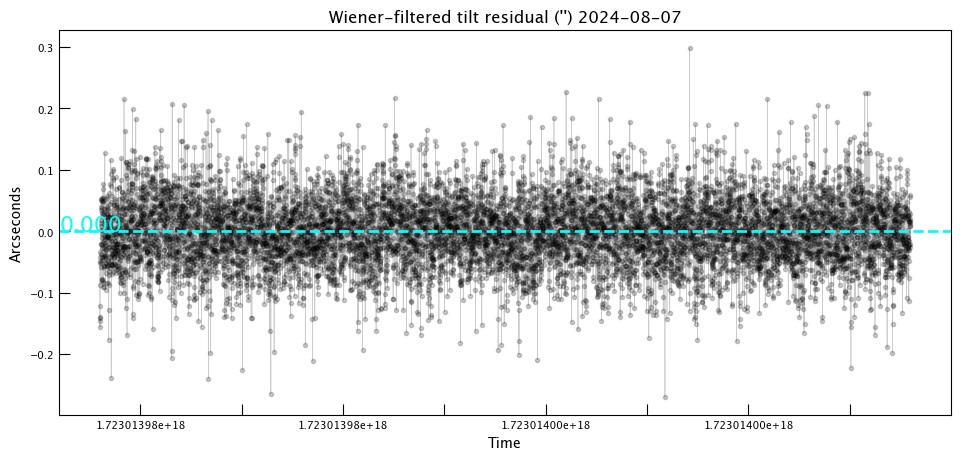

In [83]:
filtered_tilt_centroids = wiener(tilt_centroids) # Use noise=None so that function estimates noise as the average of the local variance of input tip centroids

plt.figure(figsize=(10.0, 5.0))
plt.plot(strap_telemetry['rawtimestamp'], filtered_tilt_centroids, 'k.-', linewidth=0.5, alpha=0.2)
plt.axhline(y=np.mean(filtered_tilt_centroids), color='cyan', linestyle='--', linewidth=2, 
            label=r"$\bar{\mathtt{residual tip}}$ arcsec")
plt.text(plt.xlim()[0], np.mean(filtered_tilt_centroids)*1.03, s=f"{np.mean(filtered_tilt_centroids):.3f}", color='cyan')
plt.title("Wiener-filtered tilt residual (\'\') 2024-08-07", fontsize=12.0)
plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
plt.ylabel("Arcseconds", fontsize=10.0)
for label in plt.gca().xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xlabel("Time", fontsize=10.0)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")

Compute noise-equivalent angle using Wiener-filtered tip-tilt signals

In [84]:
sigma_theta_tip = np.std(filtered_tip_centroids)
sigma_theta_tilt = np.std(filtered_tilt_centroids)
print(f"Noise equivalent angles from tip and tilt = {sigma_theta_tip} arcsec from tip and {sigma_theta_tilt} arcsec from tilt")

Noise equivalent angles from tip and tilt = 0.056513174030294704 arcsec from tip and 0.0542747170311238 arcsec from tilt


### **Fourier analysis of tip/tilt residuals**

In [87]:
from scipy import optimize, fftpack
from astroML.filters import savitzky_golay, wiener_filter

t = strap_telemetry['rawtimestamp']*(1e-9)
N = len(tip_centroids)
dt = np.mean(np.diff(strap_telemetry['rawtimestamp']))*(1e-9) # convert from ns to s
df = 1. / N / dt
f = fftpack.ifftshift(df * (np.arange(N) - N / 2))
HN = fftpack.fft(tip_centroids)

In [88]:
# Set up Wiener filter
h_smooth, PSD, P_S, P_N, Phi = wiener_filter(t, tip_centroids, return_PSDs=True)

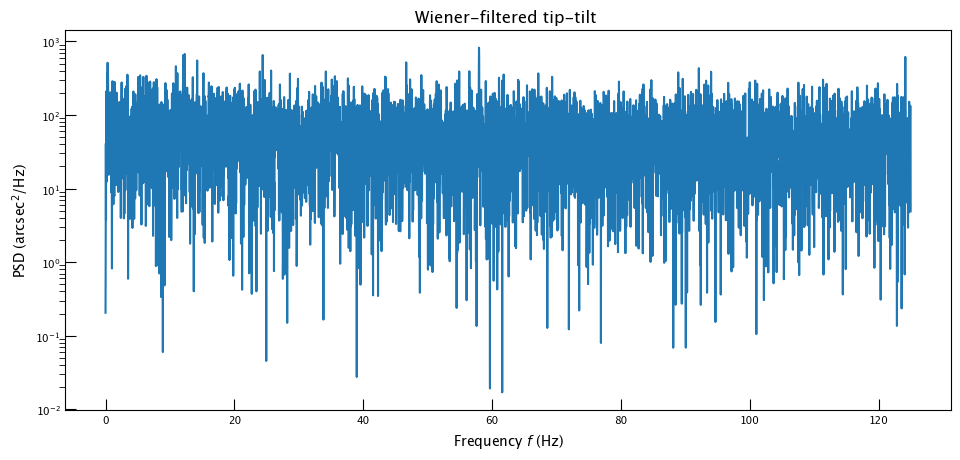

In [92]:
plt.figure(figsize=(10.0, 5.0))
plt.semilogy(f[:int(N/2)], PSD[:int(N/2)], label="Wiener-filter PSD")
# plt.semilogy(f[:int(N/2)], P_S[:int(N/2)], label="Signal PSD within Wiener filter", color="black")
# plt.loglog(f[:int(N/2)], P_N[:int(N/2)], label="Noise PSD within Wiener filter")
plt.title("Wiener-filtered tip-tilt ", fontsize=12.0)
plt.ylabel(r"PSD (arcsec$^{2}$/Hz)", fontsize=10.0)
plt.xlabel(r"Frequency $f$ (Hz)", fontsize=10.0)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")

#### **LGSWFS**

##### *SNR*

Following KAON 422 equations

In [ ]:
# Centroid errors/residuals in arcseconds for SHWFS
shwfs_centroids = ocam2k_telemetry['SHWFS1Centroid']
# Standard deviation across all subapertures -- change this to restrict to certain subapertures if SNR calculation needs to be fine-tuned
sigma_all_subap = np.std(np.abs(shwfs_centroids), axis=1)
# SNR = theta (spot size) / sigma_arcsec
# Spot size in arcseconds - try 1.5'' for known LGS spot size
spot = 1.5
SNR_KAON422 = spot / sigma_all_subap

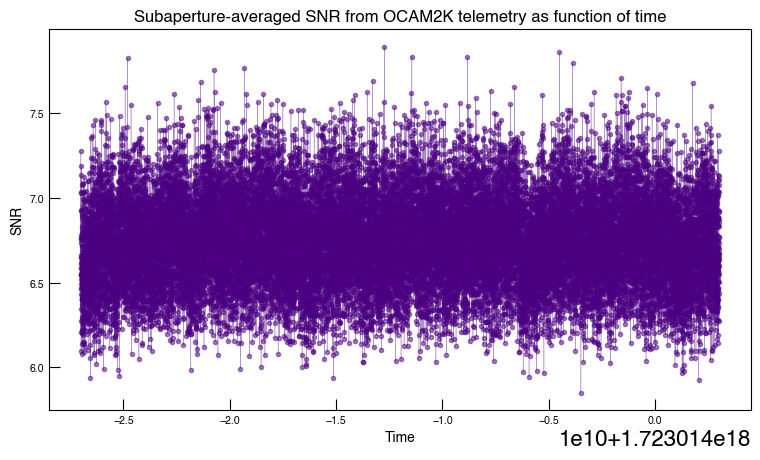

In [ ]:
plt.figure(figsize=(8.0, 5.0))
plt.plot(ocam2k_telemetry['rawtimestamp'], SNR_KAON422, '.-', linewidth=0.3, alpha=0.5, color="indigo")
plt.title("Subaperture-averaged SNR from OCAM2K telemetry as function of time", fontsize=12.0)
plt.ylabel("SNR", fontsize=10.0)
plt.xlabel("Time", fontsize=10.0)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")
plt.show()

In [ ]:
print(f"SNR calculated from telemetry centroid error standard deviation (subaperture averaged and time averaged) = {np.mean(SNR_KAON422)}")

SNR calculated from telemetry centroid error standard deviation (subaperture averaged and time averaged) = 6.745968971488814


In [ ]:
# Centroid errors/residuals in arcseconds for SHWFS
shwfs_centroids_x = ocam2k_telemetry['SHWFS1Centroid'][:,::2]
shwfs_centroids_y = ocam2k_telemetry['SHWFS1Centroid'][:,1::2]
# Standard deviation across all subapertures -- change this to restrict to certain subapertures if SNR calculation needs to be fine-tuned
sigma_by_subap = np.std(np.abs(shwfs_centroids_x), axis=0)
# SNR = theta (spot size) / sigma_arcsec
# Spot size in arcseconds - try 1.5'' -> 1.93 '' (KAON 1317) for known LGS spot size
spot = 1.93
SNR_KAON422_timeavg = spot / sigma_by_subap

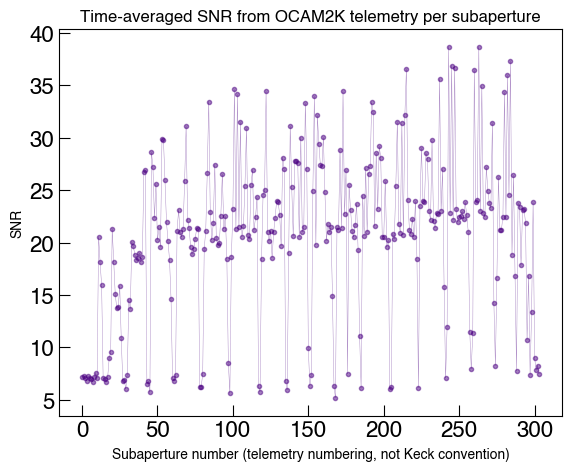

In [ ]:
fig, axes = plt.subplots(figsize=(6.0, 5.0))
plt.plot(SNR_KAON422_timeavg, '.-', linewidth=0.3, alpha=0.5, color="indigo")
plt.title("Time-averaged SNR from OCAM2K telemetry per subaperture", fontsize=12.0)
# plt.ylim(0.0, 0.7)
# plt.xlim(0.0, 0.7)
xlim = plt.gca().get_xlim()
plt.gca().tick_params(axis='both', direction='in')
plt.ylabel("SNR", fontsize=10.0)
plt.xlabel("Subaperture number (telemetry numbering, not Keck convention)", fontsize=10.0)
plt.tight_layout()
# plt.legend(ncol=1, frameon=False, fontsize="11")
# plt.savefig('/Users/bdigia/work/ao/strehl_plot_20241113_final.png', dpi=fig.dpi)
plt.show()

In [ ]:
np.mean(SNR_KAON422_timeavg[SNR_KAON422_timeavg > 20])

25.07271651352803

In [ ]:
len(SNR_KAON422_timeavg[SNR_KAON422_timeavg > 20])

199

The less illuminated subapertures bring down the SNR subaperture-average considerably. Looking at the group of reliably illuminated subapertures $> 15$ SNR (likely type 1), it looks like the time-averaged SNR for this night of telemetry was $\sim 20$ 

In [ ]:
# compare to keck_nea_photons prediction

# LGSWFS parameters (OCAM2K, not CCD39)
band = "R" # not actually at V-band
side = 0.563
ps = 3.0
sigma_e = 6.5
theta_beta = 1.5 * ( np.pi/180.0 ) / ( 60.0*60.0 )
throughput = 0.36
pix_per_ap = 4
# Use integration time from telemetry timestamp interval
time = np.mean(np.diff(ocam2k_telemetry['rawtimestamp']))*(1e-9) # seconds
# Need magnitude of star used in telemetry
m = 8.1

Np, Nb = mu.n_photons(side, time, m, band, ps, throughput)
print(Np, Nb)
SNR = Np / np.sqrt(Np + pix_per_ap*Nb + pix_per_ap*sigma_e**2)
SNR

682.2601586023783 0.0809454646373532


23.379557091255958

### **Clare 2006 Error Breakdown with Telemetry**